In [89]:
import pandas as pd
import numpy as np

In [90]:
guerra = pd.read_excel("../data/UcdpPrioConflict_v26_1.xlsx")
guerra.shape
guerra.head()
guerra.info()

<class 'pandas.DataFrame'>
RangeIndex: 2816 entries, 0 to 2815
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   conflict_id           2816 non-null   int64         
 1   location              2816 non-null   str           
 2   side_a                2816 non-null   str           
 3   side_a_id             2816 non-null   object        
 4   side_a_2nd            479 non-null    str           
 5   side_b                2816 non-null   str           
 6   side_b_id             2816 non-null   object        
 7   side_b_2nd            147 non-null    str           
 8   incompatibility       2816 non-null   int64         
 9   territory_name        1586 non-null   str           
 10  year                  2816 non-null   int64         
 11  intensity_level       2816 non-null   int64         
 12  cumulative_intensity  2816 non-null   int64         
 13  type_of_conflict      2816 no

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [91]:
guerra = guerra[["location", "side_a", "side_a_2nd", "side_b", "side_b_2nd", "territory_name", "year", "start_date", "start_date2", "ep_end_date"]]
guerra["start_date"] = pd.to_datetime(guerra["start_date"])
guerra = guerra[guerra["start_date"].dt.year.between(2013, 2017)]
guerra = guerra.sort_values("start_date")
guerra.head(22)

,location,side_a,side_a_2nd,side_b,side_b_2nd,territory_name,year,start_date,start_date2,ep_end_date
2572,Malaysia,Government of Malaysia,NaN,Sultanate of Sulu,NaN,Sabah,2013,2013-03-01,2013-03-02,2013-04-24
2627,Syria,Government of Syria,Government of United States of America,IS,NaN,Islamic State,2025,2013-03-26,2013-07-25,NaT
2626,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2024,2013-03-26,2013-07-25,NaT
2551,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2016,2013-03-26,2013-07-25,NaT
2625,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2023,2013-03-26,2013-07-25,NaT
1225,Syria,Government of Syria,NaN,IS,NaN,Islamic State,2014,2013-03-26,2013-07-25,NaT
2624,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2022,2013-03-26,2013-07-25,NaT
2623,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2021,2013-03-26,2013-07-25,NaT
2622,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2020,2013-03-26,2013-07-25,NaT
1974,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2015,2013-03-26,2013-07-25,NaT


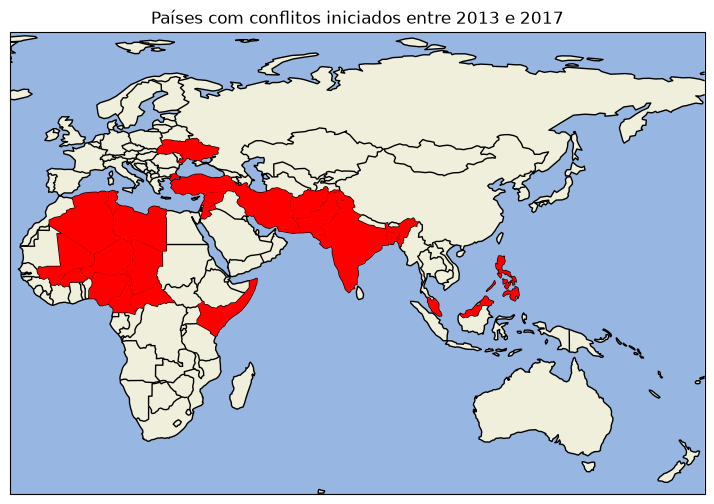

In [118]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# Países presentes nos dados
locais = guerra["location"].dropna().unique()

# Mapa
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-20, 180, -50, 83], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)

# Arquivo com os países
arquivo = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

paises = shpreader.Reader(arquivo).records()

for pais in paises:
    nome = pais.attributes["ADMIN"]

    if nome in locais:
        ax.add_geometries(
            [pais.geometry],
            ccrs.PlateCarree(),
            facecolor="red"
        )

plt.title("Países com conflitos iniciados entre 2013 e 2017")
plt.show()

In [93]:
conflitos_pais = guerra.groupby("location").size().reset_index(name="quantidade")
conflitos_pais = conflitos_pais.sort_values("quantidade", ascending=False)
conflitos_pais

,location,quantidade
25,Syria,18
4,Cameroon,15
28,Ukraine,12
19,Nigeria,11
12,Kenya,11
0,Afghanistan,11
18,Niger,11
17,Mali,10
21,Philippines,9
7,DR Congo (Zaire),9


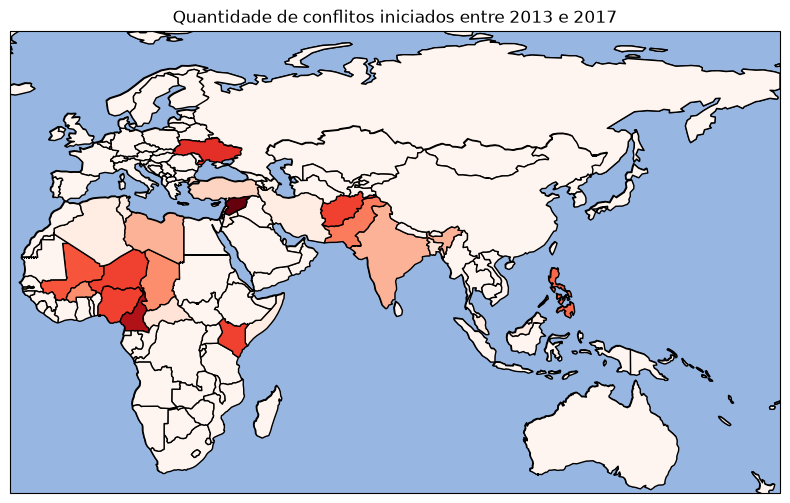

In [101]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

contagem = guerra["location"].value_counts().to_dict()

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-20, 180, -40, 80], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)

arquivo = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

paises = shpreader.Reader(arquivo).records()

normalizador = colors.Normalize(
    vmin=0,
    vmax=max(contagem.values())
)

for pais in paises:

    nome = pais.attributes["ADMIN"]

    quantidade = contagem.get(nome, 0)

    cor = cm.Reds(normalizador(quantidade))

    ax.add_geometries(
        [pais.geometry],
        ccrs.PlateCarree(),
        facecolor=cor,
        edgecolor="black"
    )

plt.title("Quantidade de conflitos iniciados entre 2013 e 2017")
plt.show()

In [95]:
import cartopy.io.shapereader as shpreader

# Arquivo de países do Natural Earth
arquivo = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

paises = shpreader.Reader(arquivo).records()

# Criar dicionário: país -> continente
continentes = {}

for pais in paises:
    nome = pais.attributes["ADMIN"]
    continente = pais.attributes["CONTINENT"]

    continentes[nome] = continente

In [96]:
guerra["continente"] = guerra["location"].map(continentes)

In [97]:
guerra = guerra[
    guerra["continente"].isin(["Europe", "Asia", "Africa"])
]

In [98]:
import pandas as pd
import cartopy.io.shapereader as shpreader

guerra = guerra[[
    "location",
    "side_a",
    "side_a_2nd",
    "side_b",
    "side_b_2nd",
    "territory_name",
    "year",
    "start_date",
    "start_date2",
    "ep_end_date"
]]

# Converter para data
guerra["start_date"] = pd.to_datetime(guerra["start_date"])

# Somente 2013 até 2017
guerra = guerra[
    guerra["start_date"].dt.year.between(2013, 2017)
]

# Natural Earth
arquivo = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

paises = shpreader.Reader(arquivo).records()

continentes = {}

for pais in paises:
    continentes[pais.attributes["ADMIN"]] = pais.attributes["CONTINENT"]

# Adicionar continente
guerra["continente"] = guerra["location"].map(continentes)

# Somente Europa, Ásia e África
guerra = guerra[
    guerra["continente"].isin(["Europe", "Asia", "Africa"])
]

# Ordenar pela data
guerra = guerra.sort_values("start_date")

guerra.head(22)

,location,side_a,side_a_2nd,side_b,side_b_2nd,territory_name,year,start_date,start_date2,ep_end_date,continente
2572,Malaysia,Government of Malaysia,NaN,Sultanate of Sulu,NaN,Sabah,2013,2013-03-01,2013-03-02,2013-04-24,Asia
2615,Syria,Government of Syria,NaN,IS,NaN,Islamic State,2013,2013-03-26,2013-07-25,NaT,Asia
2708,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2017,2013-03-26,2013-07-25,NaT,Asia
2620,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2018,2013-03-26,2013-07-25,NaT,Asia
2621,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2019,2013-03-26,2013-07-25,NaT,Asia
1974,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2015,2013-03-26,2013-07-25,NaT,Asia
2623,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2021,2013-03-26,2013-07-25,NaT,Asia
2622,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2020,2013-03-26,2013-07-25,NaT,Asia
1225,Syria,Government of Syria,NaN,IS,NaN,Islamic State,2014,2013-03-26,2013-07-25,NaT,Asia
2625,Syria,Government of Syria,"Government of Iran, Government of Russia (Sovi...",IS,NaN,Islamic State,2023,2013-03-26,2013-07-25,NaT,Asia


In [99]:
guerra.groupby(
    [guerra["start_date"].dt.year, "continente"]
).size()

start_date  continente
2013        Asia          14
2014        Africa         1
            Asia           3
            Europe        12
2015        Africa        55
            Asia          26
2016        Africa         1
            Asia          19
2017        Africa        25
dtype: int64

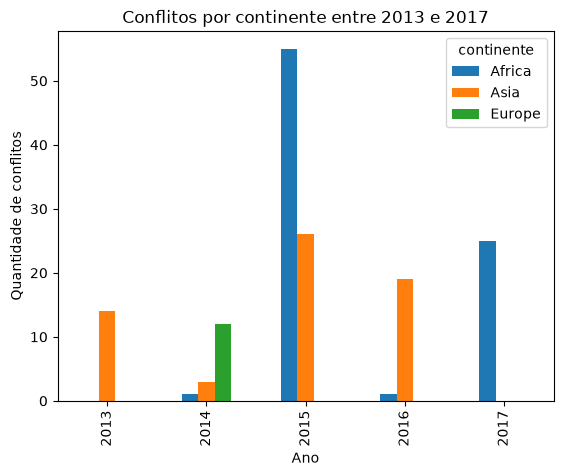

In [100]:
dados = guerra.groupby(
    [guerra["start_date"].dt.year, "continente"]
).size().unstack(fill_value=0)

dados.plot(kind="bar")

plt.xlabel("Ano")
plt.ylabel("Quantidade de conflitos")
plt.title("Conflitos por continente entre 2013 e 2017")
plt.show()